# 02 Funding Landscape

**Goal:** Produce baseline charts covering the one-variable distributions that anchor all later analyses.

Sections:
1. Setup & data load
2. Grant amount distributions (linear + log scale)
3. Grant duration
4. Grants per year (count)
5. Agency frequency
6. Department / college frequency
7. Faculty rank distribution
8. Tenure status distribution
9. Co-PI rate

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')

# Resolve repo root
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'data' / 'processed').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
OUTPUTS_DIR   = REPO_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)
print('Repo root:', REPO_ROOT)

Repo root: /Users/uttkarshnarayan/projects/northeastern_visualization


In [2]:
faculty      = pd.read_parquet(PROCESSED_DIR / 'faculty.parquet')
grants       = pd.read_parquet(PROCESSED_DIR / 'grants.parquet')
faculty_grants = pd.read_parquet(PROCESSED_DIR / 'faculty_grants.parquet')

print(f'faculty:       {faculty.shape}')
print(f'grants:        {grants.shape}')
print(f'faculty_grants: {faculty_grants.shape}')
print()
print('grant columns:', list(grants.columns))
print('faculty columns:', list(faculty.columns))

faculty:       (2247, 12)
grants:        (2676, 18)
faculty_grants: (3144, 5)

grant columns: ['grant_id', 'grantname', 'agencycode', 'agencyname', 'agencygrantid', 'totaldollars', 'dollarsperyear', 'durationinyears', 'startdate', 'enddate', 'awarddate', 'startdateyear', 'countrycode', 'isgovernment', 'isresearch', 'pi_names_available', 'db_coverage', 'copi_available']
faculty columns: ['faculty_id', 'faculty_name', 'superior_academic_unit', 'academic_unit', 'academic_track_type', 'academic_rank', 'tenure_status', 'location_address_country', 'hire_date', 'terminal_degrees', 'termination_date', 'termination_status']


## 1 · Grant Amount Distributions

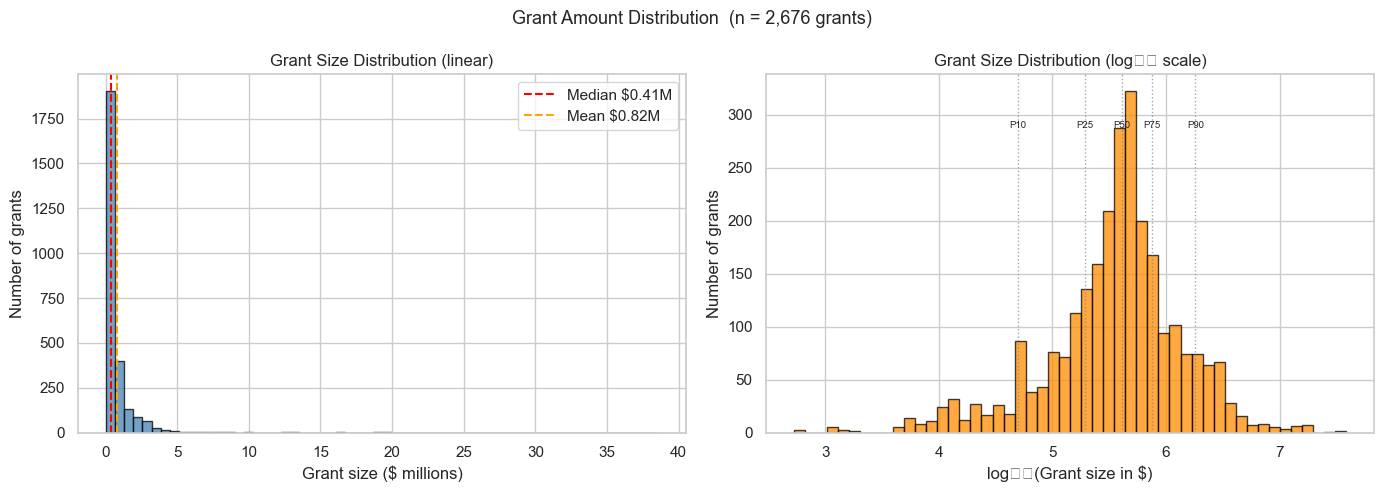


Summary statistics (USD):
count         $2,676
mean        $815,941
std       $1,867,691
min             $527
25%         $193,647
50%         $412,028
75%         $745,958
max      $38,591,094
Name: totaldollars, dtype: object


In [3]:
dollars = grants['totaldollars'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(dollars / 1e6, bins=60, edgecolor='black', alpha=0.75, color='steelblue')
axes[0].set_xlabel('Grant size ($ millions)')
axes[0].set_ylabel('Number of grants')
axes[0].set_title('Grant Size Distribution (linear)')
axes[0].axvline(dollars.median() / 1e6, color='red', linestyle='--',
                label=f'Median ${dollars.median()/1e6:.2f}M')
axes[0].axvline(dollars.mean() / 1e6, color='orange', linestyle='--',
                label=f'Mean ${dollars.mean()/1e6:.2f}M')
axes[0].legend()

# Log scale
log_dollars = np.log10(dollars[dollars > 0])
axes[1].hist(log_dollars, bins=50, edgecolor='black', alpha=0.75, color='darkorange')
axes[1].set_xlabel('log₁₀(Grant size in $)')
axes[1].set_ylabel('Number of grants')
axes[1].set_title('Grant Size Distribution (log₁₀ scale)')
# annotate deciles
for p in [10, 25, 50, 75, 90]:
    v = np.percentile(log_dollars, p)
    axes[1].axvline(v, color='grey', linestyle=':', alpha=0.7, linewidth=1)
    axes[1].text(v, axes[1].get_ylim()[1]*0.85, f'P{p}', ha='center', fontsize=7)

plt.suptitle(f'Grant Amount Distribution  (n = {len(dollars):,} grants)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w4_grant_amount_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSummary statistics (USD):')
print(dollars.describe().apply(lambda x: f'${x:,.0f}'))

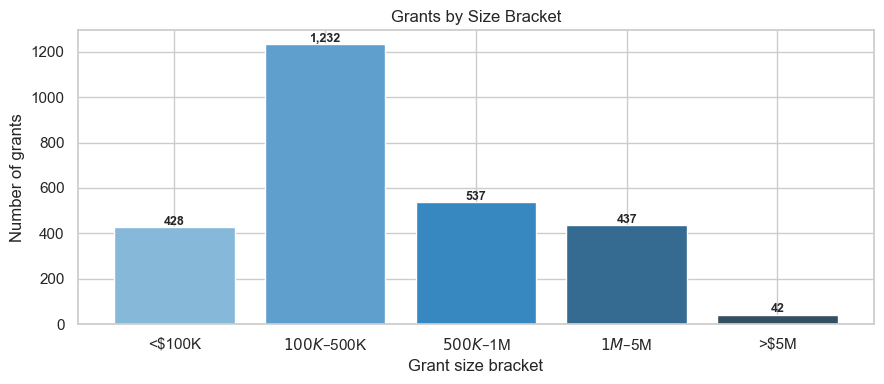

In [4]:
# Box-plot by size bracket
brackets = pd.cut(dollars,
                  bins=[0, 100_000, 500_000, 1_000_000, 5_000_000, dollars.max()],
                  labels=['<$100K', '$100K–$500K', '$500K–$1M', '$1M–$5M', '>$5M'])
bracket_counts = brackets.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(bracket_counts.index, bracket_counts.values,
              color=sns.color_palette('Blues_d', len(bracket_counts)))
for bar, v in zip(bars, bracket_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 10, f'{v:,}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Grant size bracket')
ax.set_ylabel('Number of grants')
ax.set_title('Grants by Size Bracket')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w4_grant_size_brackets.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 · Grant Duration

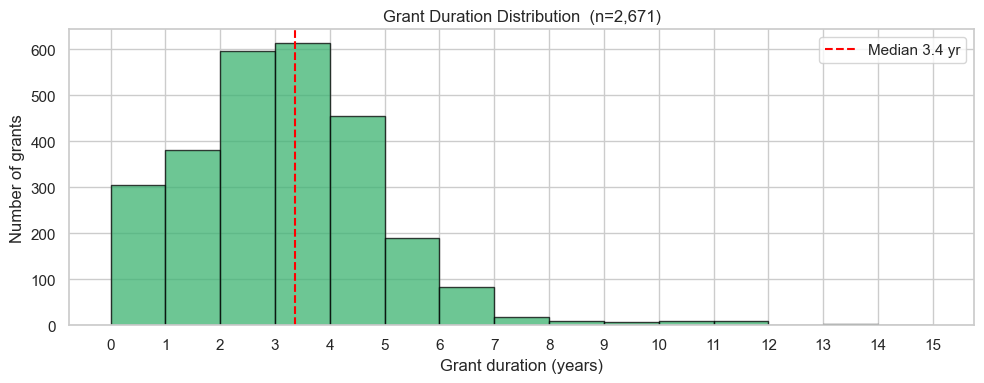

0.164271     1
0.167009     1
0.331280     1
0.416153     1
0.454483     3
            ..
11.950719    1
12.777550    1
13.259411    1
13.675565    1
14.663929    1
Name: n_grants, Length: 549, dtype: int64


In [5]:
# Compute duration in years from start/end year columns (or dates)
if 'startdateyear' in grants.columns and 'enddateyear' in grants.columns:
    dur = (grants['enddateyear'] - grants['startdateyear']).dropna()
    dur = dur[(dur >= 0) & (dur <= 15)]  # sanity filter
elif 'startdate' in grants.columns and 'enddate' in grants.columns:
    dur = ((pd.to_datetime(grants['enddate']) - pd.to_datetime(grants['startdate']))
           .dt.days / 365.25).dropna()
    dur = dur[(dur >= 0) & (dur <= 15)]
else:
    print('No date columns found; skipping duration analysis')
    dur = pd.Series(dtype=float)

if len(dur) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(dur, bins=range(0, 16), edgecolor='black', alpha=0.75, color='mediumseagreen')
    ax.set_xlabel('Grant duration (years)')
    ax.set_ylabel('Number of grants')
    ax.set_title(f'Grant Duration Distribution  (n={len(dur):,})')
    ax.axvline(dur.median(), color='red', linestyle='--',
               label=f'Median {dur.median():.1f} yr')
    ax.legend()
    ax.set_xticks(range(0, 16))
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'w4_grant_duration.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(dur.value_counts().sort_index().rename('n_grants'))

## 3 · Grants per Year

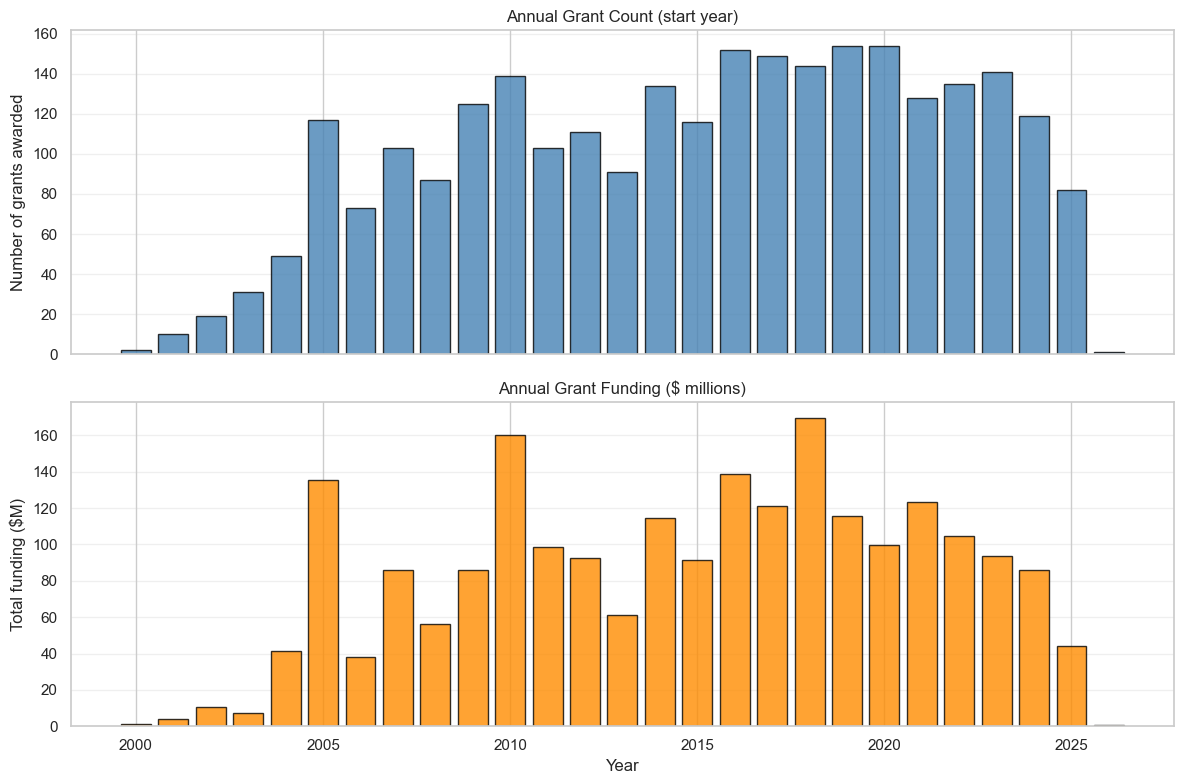

,year,n_grants,total_dollars
20,2017,149,121050773
21,2018,144,169548876
22,2019,154,115568006
23,2020,154,99941161
24,2021,128,123551183
25,2022,135,104506914
26,2023,141,93840883
27,2024,119,85884508
28,2025,82,44199266
29,2026,1,900000


In [6]:
year_col = 'startdateyear' if 'startdateyear' in grants.columns else None
if year_col:
    yearly = (grants.groupby(year_col)
              .agg(n_grants=('grant_id', 'nunique'),
                   total_dollars=('totaldollars', 'sum'))
              .reset_index()
              .rename(columns={year_col: 'year'}))
    yearly = yearly[(yearly['year'] >= 2000) & (yearly['year'] <= 2026)]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].bar(yearly['year'], yearly['n_grants'], color='steelblue', edgecolor='black', alpha=0.8)
    axes[0].set_ylabel('Number of grants awarded')
    axes[0].set_title('Annual Grant Count (start year)')
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(yearly['year'], yearly['total_dollars'] / 1e6,
                color='darkorange', edgecolor='black', alpha=0.8)
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Total funding ($M)')
    axes[1].set_title('Annual Grant Funding ($ millions)')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'w4_grants_per_year.png', dpi=150, bbox_inches='tight')
    plt.show()
    display(yearly.tail(10))

## 4 · Agency Frequency

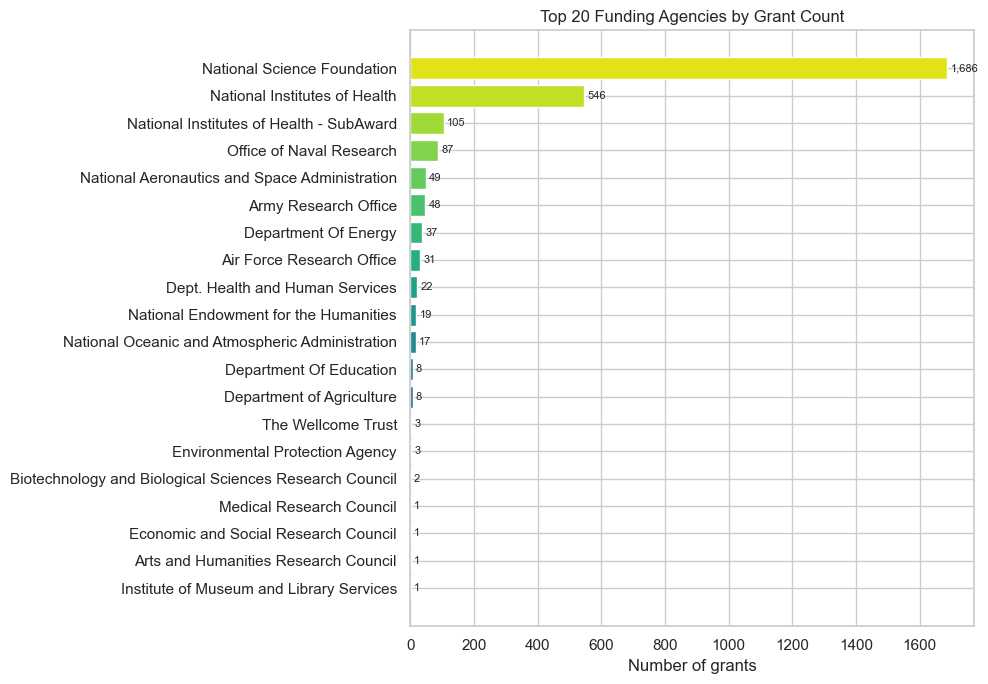

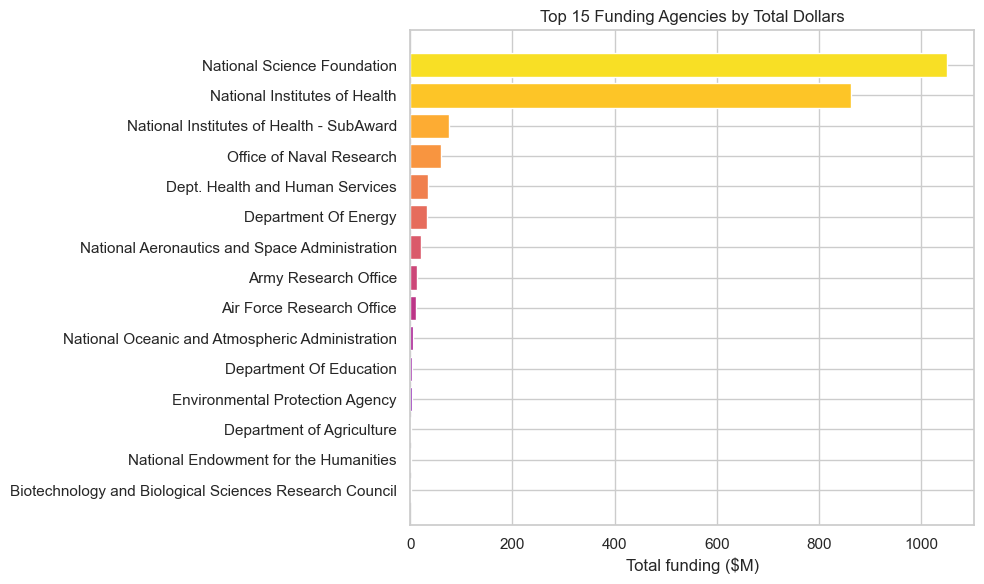

In [7]:
agency_col = 'agencyname' if 'agencyname' in grants.columns else 'agencycode'
top_agencies = (grants[agency_col]
                .value_counts()
                .head(20)
                .reset_index()
                .rename(columns={agency_col: 'agency', 'count': 'n_grants'}))
# handle pandas ≥2.0 value_counts naming
if 'index' in top_agencies.columns:
    top_agencies.columns = ['agency', 'n_grants']

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_agencies['agency'][::-1], top_agencies['n_grants'][::-1],
               color=sns.color_palette('viridis', len(top_agencies)))
for bar, v in zip(bars, top_agencies['n_grants'][::-1]):
    ax.text(v + 10, bar.get_y() + bar.get_height()/2, f'{v:,}',
            va='center', fontsize=8)
ax.set_xlabel('Number of grants')
ax.set_title('Top 20 Funding Agencies by Grant Count')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w4_agency_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

# Also show by total dollars
agency_dollars = (grants.groupby(agency_col)['totaldollars']
                  .sum()
                  .sort_values(ascending=False)
                  .head(15)
                  .reset_index())
agency_dollars.columns = ['agency', 'total_dollars']
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.barh(agency_dollars['agency'][::-1], agency_dollars['total_dollars'][::-1] / 1e6,
         color=sns.color_palette('plasma', len(agency_dollars)))
ax2.set_xlabel('Total funding ($M)')
ax2.set_title('Top 15 Funding Agencies by Total Dollars')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w4_agency_dollars.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Department & College Frequency

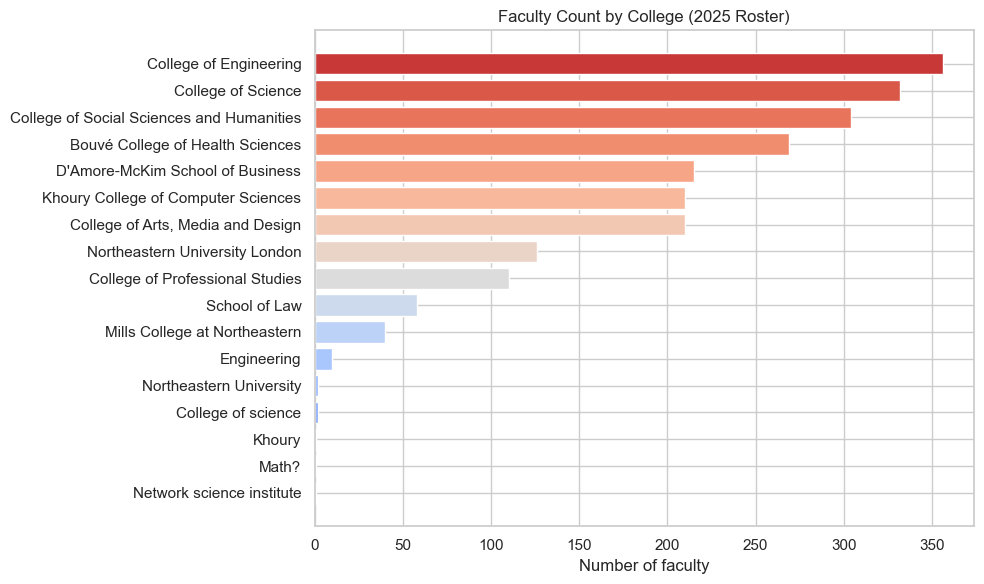

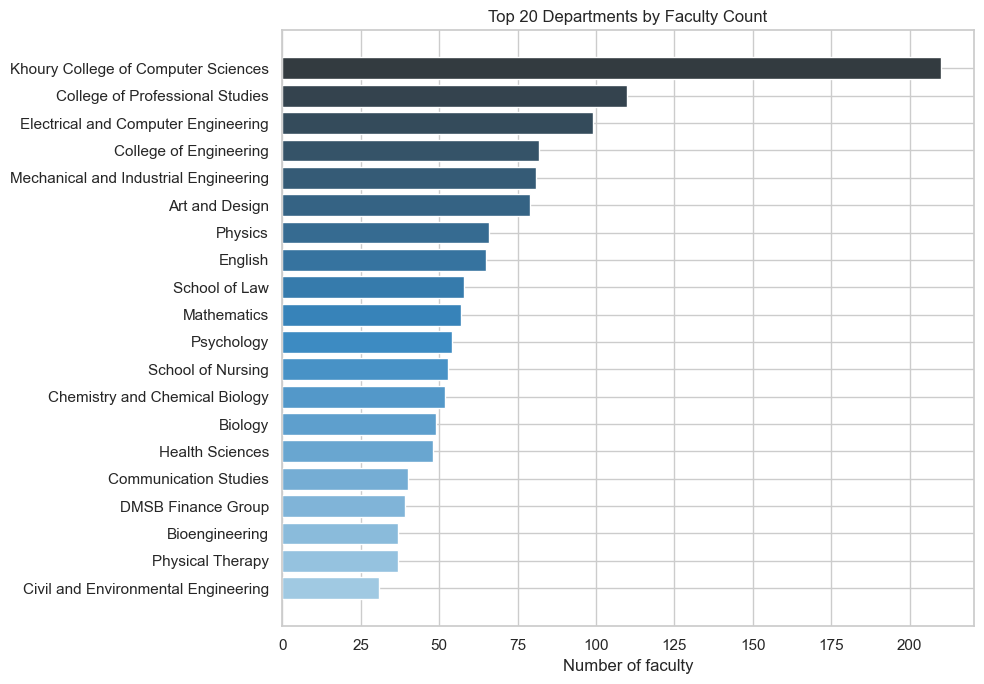

In [8]:
# College breakdown from faculty roster
college_counts = (faculty
                  .groupby('superior_academic_unit')['faculty_id']
                  .nunique()
                  .sort_values(ascending=False)
                  .reset_index())
college_counts.columns = ['college', 'n_faculty']

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(college_counts['college'][::-1], college_counts['n_faculty'][::-1],
        color=sns.color_palette('coolwarm', len(college_counts)))
ax.set_xlabel('Number of faculty')
ax.set_title('Faculty Count by College (2025 Roster)')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w4_college_faculty_count.png', dpi=150, bbox_inches='tight')
plt.show()

# Department (Academic Unit) breakdown - top 20
dept_counts = (faculty
               .groupby('academic_unit')['faculty_id']
               .nunique()
               .sort_values(ascending=False)
               .head(20)
               .reset_index())
dept_counts.columns = ['department', 'n_faculty']

fig2, ax2 = plt.subplots(figsize=(10, 7))
ax2.barh(dept_counts['department'][::-1], dept_counts['n_faculty'][::-1],
         color=sns.color_palette('Blues_d', len(dept_counts)))
ax2.set_xlabel('Number of faculty')
ax2.set_title('Top 20 Departments by Faculty Count')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w4_dept_faculty_count.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Faculty Rank & Tenure Status

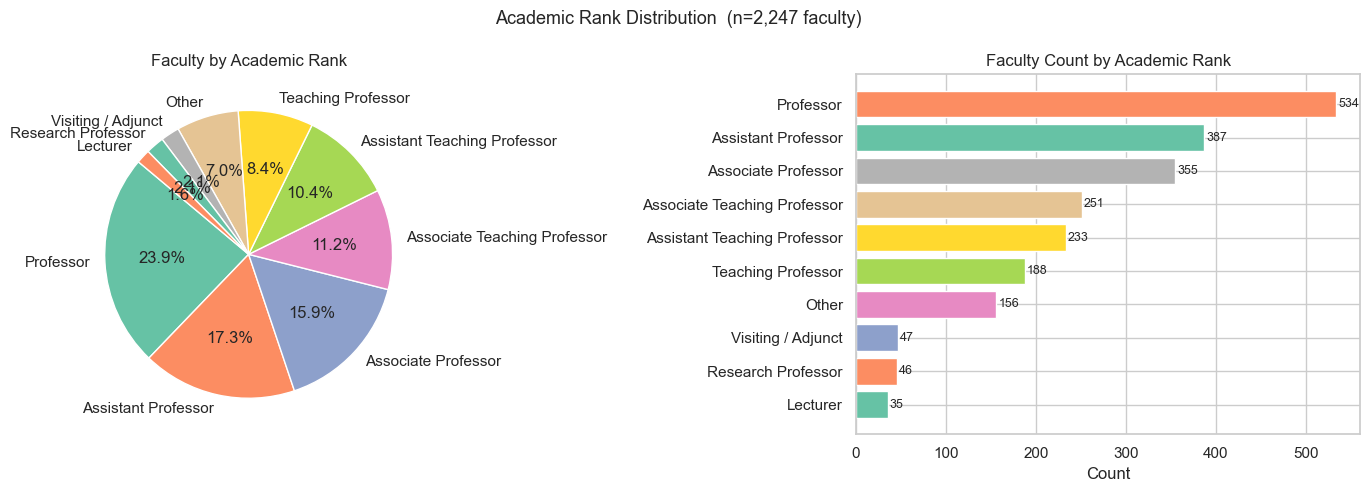

In [9]:
rank_counts = (faculty['academic_rank']
               .value_counts()
               .reset_index())
rank_counts.columns = ['rank', 'n']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(rank_counts['n'], labels=rank_counts['rank'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(rank_counts)))
axes[0].set_title('Faculty by Academic Rank')

# Bar chart
axes[1].barh(rank_counts['rank'][::-1], rank_counts['n'][::-1],
             color=sns.color_palette('Set2', len(rank_counts)))
axes[1].set_xlabel('Count')
axes[1].set_title('Faculty Count by Academic Rank')
for i, v in enumerate(rank_counts['n'][::-1]):
    axes[1].text(v + 2, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle(f'Academic Rank Distribution  (n={len(faculty):,} faculty)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w4_faculty_rank.png', dpi=150, bbox_inches='tight')
plt.show()

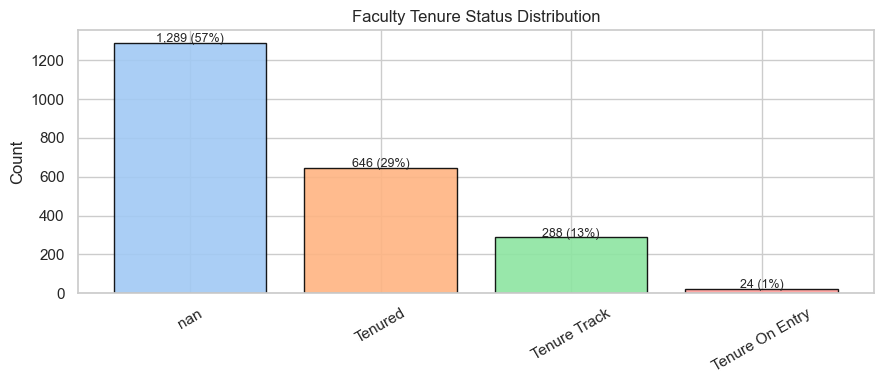

In [10]:
# Tenure status
if 'tenure_status' in faculty.columns:
    tenure_counts = (faculty['tenure_status']
                     .astype(str).fillna('Unknown')
                     .value_counts()
                     .reset_index())
    tenure_counts.columns = ['status', 'n']

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(tenure_counts['status'], tenure_counts['n'],
                  color=sns.color_palette('pastel', len(tenure_counts)),
                  edgecolor='black', alpha=0.9)
    for bar, v in zip(bars, tenure_counts['n']):
        ax.text(bar.get_x() + bar.get_width()/2, v + 3, f'{v:,} ({v/len(faculty)*100:.0f}%)',
                ha='center', fontsize=9)
    ax.set_ylabel('Count')
    ax.set_title('Faculty Tenure Status Distribution')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'w4_tenure_status.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7 · Co-PI Rate

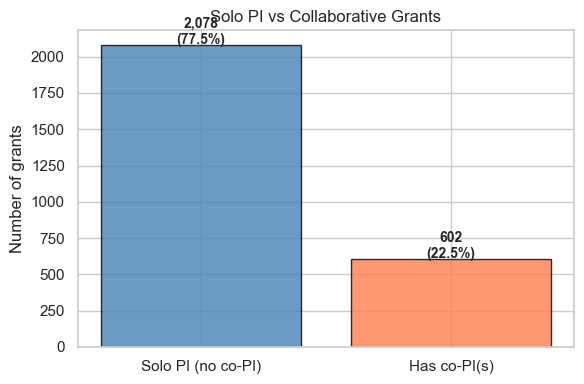

Total grants: 2,680
  Solo PI  : 2,078 (77.5%)
  With co-PI: 602 (22.5%)


In [11]:
# Per grant: is there at least one co-PI?
copi_per_grant = (faculty_grants
                  .groupby('grant_id')['is_copi']
                  .max()
                  .reset_index()
                  .rename(columns={'is_copi': 'has_copi'}))

copi_counts = copi_per_grant['has_copi'].value_counts()
solo  = copi_counts.get(0, 0)
collab = copi_counts.get(1, 0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Solo PI (no co-PI)', 'Has co-PI(s)'], [solo, collab],
       color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
for i, v in enumerate([solo, collab]):
    ax.text(i, v + 10, f'{v:,}\n({v/(solo+collab)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of grants')
ax.set_title('Solo PI vs Collaborative Grants')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w4_copi_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total grants: {solo + collab:,}')
print(f'  Solo PI  : {solo:,} ({solo/(solo+collab)*100:.1f}%)')
print(f'  With co-PI: {collab:,} ({collab/(solo+collab)*100:.1f}%)')

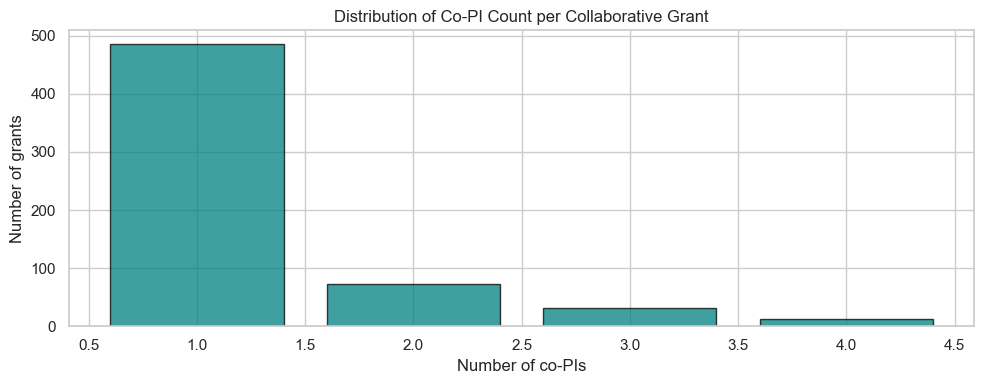

In [12]:
# Distribution of co-PIs per grant
n_copi_per_grant = (faculty_grants[faculty_grants['is_copi'] == 1]
                    .groupby('grant_id')['faculty_id']
                    .nunique()
                    .value_counts()
                    .sort_index()
                    .reset_index())
n_copi_per_grant.columns = ['n_copis', 'n_grants']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(n_copi_per_grant['n_copis'], n_copi_per_grant['n_grants'],
       color='teal', edgecolor='black', alpha=0.75)
ax.set_xlabel('Number of co-PIs')
ax.set_ylabel('Number of grants')
ax.set_title('Distribution of Co-PI Count per Collaborative Grant')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w4_copi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Summary Table

In [13]:
summary = {
    'Total faculty (2025 roster)': f"{len(faculty):,}",
    'Total unique grants': f"{grants['grant_id'].nunique():,}",
    'Total funding': f"${grants['totaldollars'].sum():,.0f}",
    'Median grant size': f"${grants['totaldollars'].median():,.0f}",
    'Mean grant size': f"${grants['totaldollars'].mean():,.0f}",
    'Largest single grant': f"${grants['totaldollars'].max():,.0f}",
    'Unique agencies': f"{grants[agency_col].nunique():,}",
    'Grants with co-PI': f"{collab:,} ({collab/(solo+collab)*100:.1f}%)",
    'Unique colleges': f"{faculty['superior_academic_unit'].nunique():,}",
    'Unique departments': f"{faculty['academic_unit'].nunique():,}",
}
pd.Series(summary, name='Value').to_frame()

,Value
Total faculty (2025 roster),"2,247"
Total unique grants,"2,676"
Total funding,"$2,183,457,207"
Median grant size,"$412,028"
Mean grant size,"$815,941"
Largest single grant,"$38,591,094"
Unique agencies,21
Grants with co-PI,602 (22.5%)
Unique colleges,17
Unique departments,91
